In [ ]:
# Iván Andrés Trujillo Abella
# ivantrujillo1229@gmail.com

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
url = "https://raw.githubusercontent.com/it-ces/Datasets/refs/heads/main/streaming-movies-prices.csv"

In [ ]:
df = pd.read_csv(url)

In [ ]:
df.groupby(by=['genre'])['price'].mean()

,price
genre,
Action,15.843144
Comedy,8.637145
Horror,19.104853
Tragedy,12.450790


In [ ]:
df.groupby(by=['genre', 'new_release'])['price'].mean()

genre    new_release
Action   No             13.024776
         Yes            18.661512
Comedy   No              6.774428
         Yes            10.499862
Horror   No             15.388788
         Yes            22.820919
Tragedy  No              9.957288
         Yes            14.944291
Name: price, dtype: float64

In [ ]:
import matplotlib.pyplot as plt
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from scipy import stats
import seaborn as sns

In [ ]:
model = smf.ols('price ~ C(new_release) * C(genre) *C(subtitled)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
display(anova_table)

,sum_sq,df,F,PR(>F)
C(new_release),8866.288449,1.0,579.979287,1.276543e-104
C(genre),18181.578336,3.0,396.443183,3.173010e-178
C(subtitled),70.945167,1.0,4.640806,3.142159e-02
C(new_release):C(genre),545.644263,3.0,11.897589,1.116022e-07
C(new_release):C(subtitled),3.307222,1.0,0.216339,6.419295e-01
C(genre):C(subtitled),41.703234,3.0,0.909325,4.358291e-01
C(new_release):C(genre):C(subtitled),58.890033,3.0,1.284077,2.783976e-01
Residual,18100.104195,1184.0,NaN,NaN


triple interaction not is significative, then uses hierarchical principle.

In [ ]:
model = smf.ols('price ~ C(genre) * C(new_release)', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=3)
print(anova_table)

                               sum_sq      df            F         PR(>F)
Intercept                25446.720171     1.0  1659.801903  4.903369e-228
C(genre)                  6296.394454     3.0   136.897374   3.278866e-76
C(new_release)            2382.958695     1.0   155.432187   1.271959e-33
C(genre):C(new_release)    536.409310     3.0    11.662711   1.554479e-07
Residual                 18274.765439  1192.0          NaN            NaN


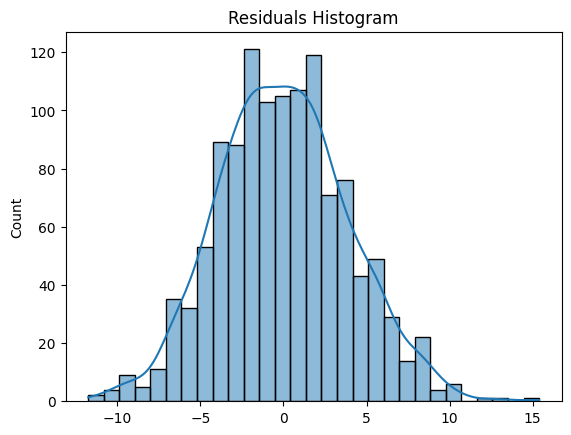

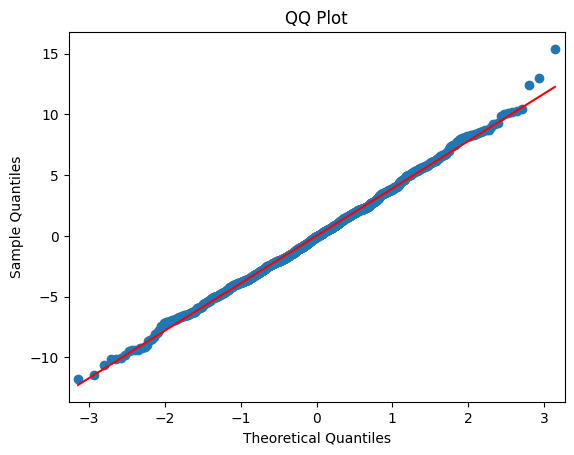

Shapiro-Wilk p-value: 0.11868346035092625


In [ ]:
residuals = model.resid

# Histogram + QQ plot
sns.histplot(residuals, kde=True)
plt.title("Residuals Histogram")
plt.show()

sm.qqplot(residuals, line='s')
plt.title("QQ Plot")
plt.show()

# Shapiro-Wilk Test
shapiro_test = stats.shapiro(residuals)
print(f"Shapiro-Wilk p-value: {shapiro_test.pvalue}")

In [ ]:
from scipy.stats import levene
levene(*df.groupby(by=['genre', 'new_release'])['price'].apply(list)).pvalue

np.float64(0.6381135029110862)

In [ ]:
from statsmodels.stats.stattools import durbin_watson

dw = durbin_watson(residuals)
print(f"Durbin-Watson statistic: {dw}")
# between 1.5 and 2.5 is ok

Durbin-Watson statistic: 2.0167560448400534


In [ ]:
tukey = pairwise_tukeyhsd(endog=df['price'],
                          groups=df['genre'] + df['new_release'],
                          alpha=0.05)
print(tukey.summary())

     Multiple Comparison of Means - Tukey HSD, FWER=0.05     
  group1    group2   meandiff p-adj   lower    upper   reject
-------------------------------------------------------------
 ActionNo  ActionYes   5.6367    0.0    4.264   7.0095   True
 ActionNo   ComedyNo  -6.2503    0.0  -7.6231  -4.8776   True
 ActionNo  ComedyYes  -2.5249    0.0  -3.8977  -1.1521   True
 ActionNo   HorrorNo    2.364    0.0   0.9912   3.7368   True
 ActionNo  HorrorYes   9.7961    0.0   8.4234  11.1689   True
 ActionNo  TragedyNo  -3.0675    0.0  -4.4403  -1.6947   True
 ActionNo TragedyYes   1.9195 0.0006   0.5467   3.2923   True
ActionYes   ComedyNo -11.8871    0.0 -13.2599 -10.5143   True
ActionYes  ComedyYes  -8.1616    0.0  -9.5344  -6.7889   True
ActionYes   HorrorNo  -3.2727    0.0  -4.6455  -1.8999   True
ActionYes  HorrorYes   4.1594    0.0   2.7866   5.5322   True
ActionYes  TragedyNo  -8.7042    0.0  -10.077  -7.3314   True
ActionYes TragedyYes  -3.7172    0.0    -5.09  -2.3444   True
 ComedyN